# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [9]:
ruta = keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [ ]:
# El archivo está sucísimo y tenía muchos trucos. La IA me ha dicho cómo había que leerlo correctamente

Importelo usando pandas.

In [27]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]
df = pd.read_csv(ruta, 
                 names=column_names,
                 na_values="?",      # Convierte los "?" en valores nulos
                 #omment='\t',       # Separa el nombre del coche (que viene tras un tabulador)
                 sep="\s+"         # El separador base es el espacio
                 #skipinitialspace=True) # ¡ESTA ES LA CLAVE! Ignora los espacios extra
)

In [28]:
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### Limpia los datos

Trata los missings y variables categóricas

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [30]:
# Quito nulos
df = df.dropna()

In [ ]:
# Hay tantos nombres casi como entradas. Por ahora lo voy a ignorar. 
df['Car name'].unique()

array(['chevrolet chevelle malibu', 'buick skylark 320',
       'plymouth satellite', 'amc rebel sst', 'ford torino',
       'ford galaxie 500', 'chevrolet impala', 'plymouth fury iii',
       'pontiac catalina', 'amc ambassador dpl', 'dodge challenger se',
       "plymouth 'cuda 340", 'chevrolet monte carlo',
       'buick estate wagon (sw)', 'toyota corona mark ii',
       'plymouth duster', 'amc hornet', 'ford maverick', 'datsun pl510',
       'volkswagen 1131 deluxe sedan', 'peugeot 504', 'audi 100 ls',
       'saab 99e', 'bmw 2002', 'amc gremlin', 'ford f250', 'chevy c20',
       'dodge d200', 'hi 1200d', 'chevrolet vega 2300', 'toyota corona',
       'plymouth satellite custom', 'ford torino 500', 'amc matador',
       'pontiac catalina brougham', 'dodge monaco (sw)',
       'ford country squire (sw)', 'pontiac safari (sw)',
       'amc hornet sportabout (sw)', 'chevrolet vega (sw)',
       'pontiac firebird', 'ford mustang', 'mercury capri 2000',
       'opel 1900', 'peugeot 304

### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop (columns=['MPG','Car name'])
y = df ['MPG']

# Como luego va a pedir validación me hago también una parte de validación
X_train_full, X_test, y_train_full, y_test = train_test_split(X,
                                                              y)

X_train, X_val, y_train, y_val = train_test_split(X_train_full,
                                                      y_train_full)

### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

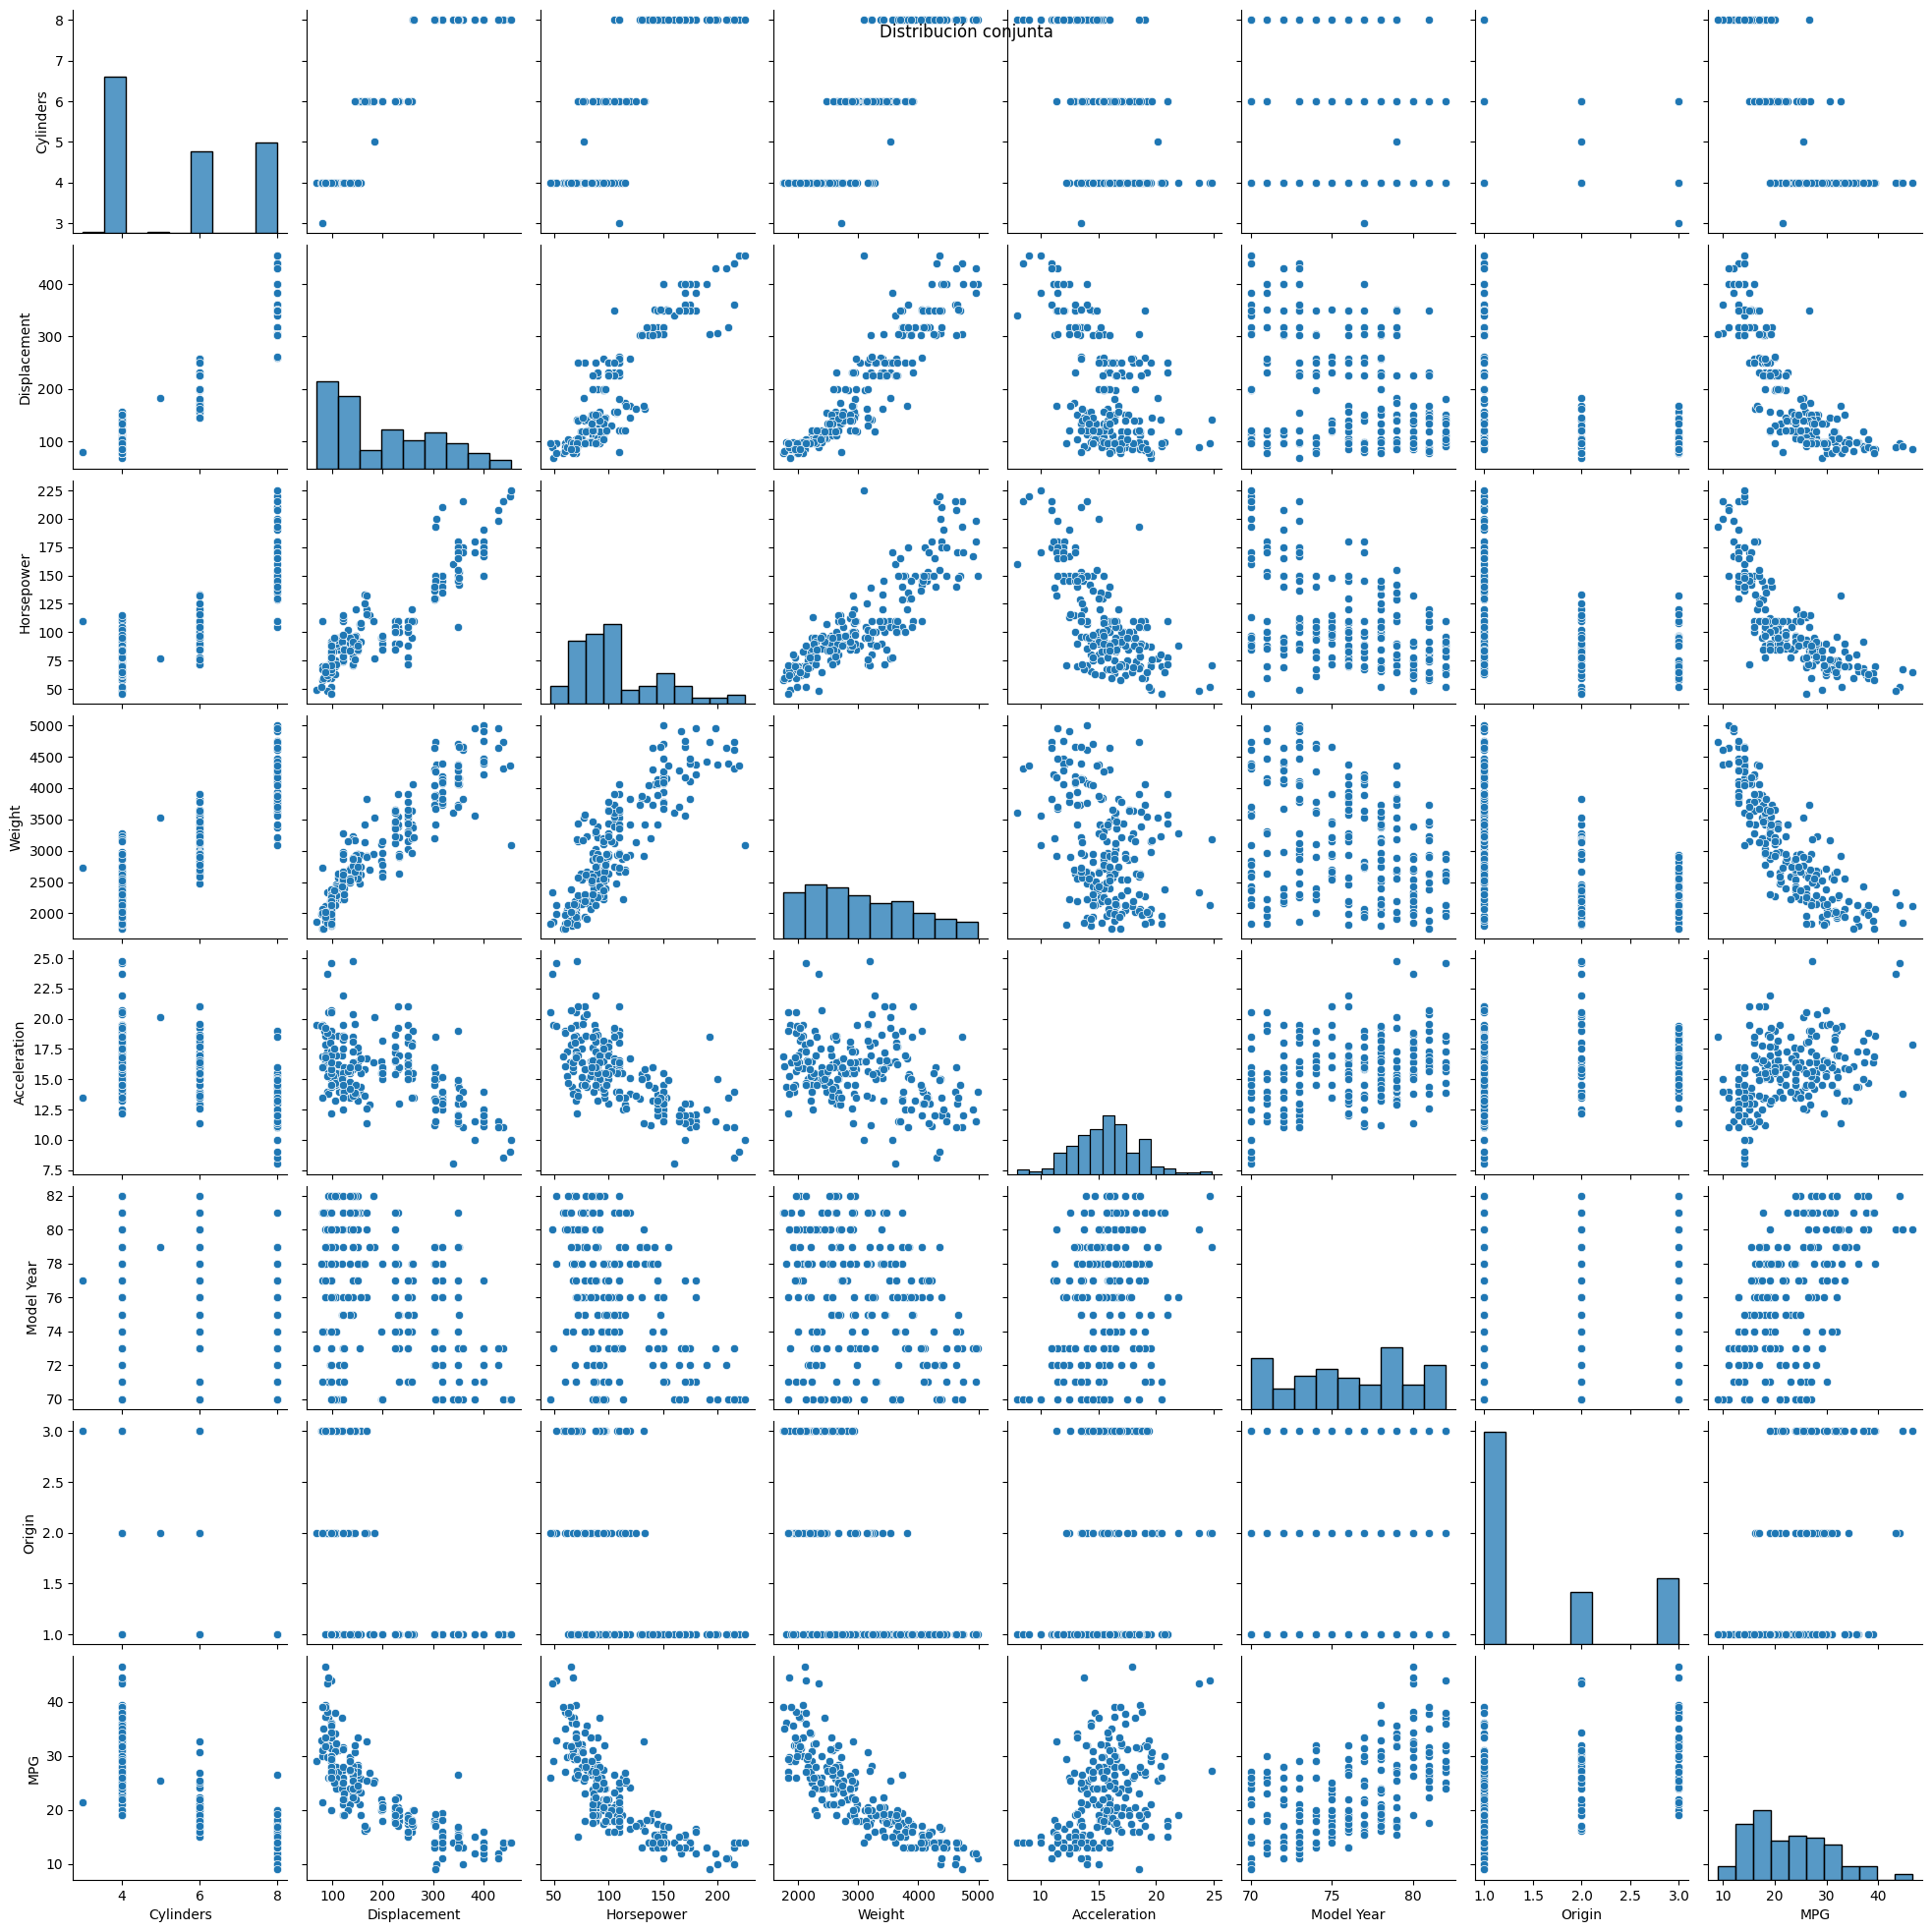

In [38]:
# Combinar X_train e y_train en un DataFrame para poder verlo en un pairplot de seaborn
df = pd.DataFrame(X_train)
df['MPG'] = y_train

# Grid de gráficos
sns.pairplot(df)
plt.suptitle('Distribución conjunta')
plt.show()

Tambien revise las estadisticas generales:

In [39]:
df.describe()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,MPG
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,5.581818,201.363636,107.236364,3060.145455,15.595455,75.931818,1.559091,22.822727
std,1.692756,104.637336,39.041934,850.699447,2.740759,3.667690,0.805891,7.810170
min,3.000000,68.000000,46.000000,1755.000000,8.000000,70.000000,1.000000,9.000000
25%,4.000000,107.000000,79.750000,2307.500000,13.775000,73.000000,1.000000,16.800000
50%,6.000000,159.500000,95.500000,2922.000000,15.500000,76.000000,1.000000,21.300000
75%,8.000000,302.000000,130.500000,3701.000000,17.050000,79.000000,2.000000,28.000000
max,8.000000,455.000000,225.000000,4997.000000,24.800000,82.000000,3.000000,46.600000


### Separa las features del target

Separe el target de las features.

In [ ]:
# Está ya separada en X_train, y_train....etc 

### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [41]:
X_train.shape

(220, 7)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [42]:

model = keras.models.Sequential([
    keras.layers.Dense(100, activation = 'relu',
                      input_shape = X_train.shape[1:]),
    keras.layers.Dense(units = 300, activation='relu'),
    keras.layers.Dense(1) # como predigo un número es 1, no tiene capa de activación porque es regresión
])

model.compile(loss = "mean_squared_error", # función de coste
             optimizer = keras.optimizers.RMSprop(0.001), #optimizador
             metrics = ['mae','mse']) 


c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 300)            │        30,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,401 (122.66 KB)

 Trainable params: 31,401 (122.66 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [46]:
history = model.fit (X_train,
                   y_train,
                   epochs = 1000,
                   validation_data = (X_val, y_val),
                   validation_split=0.2)

Epoch 1/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 505.8477 - mae: 20.9885 - mse: 505.8477 - val_loss: 419.3373 - val_mae: 18.9707 - val_mse: 419.3373
Epoch 2/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 367.6537 - mae: 17.3545 - mse: 367.6537 - val_loss: 283.5435 - val_mae: 15.0246 - val_mse: 283.5435
Epoch 3/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 244.7002 - mae: 13.7529 - mse: 244.7002 - val_loss: 174.0320 - val_mae: 11.4419 - val_mse: 174.0320
Epoch 4/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 145.3657 - mae: 10.5809 - mse: 145.3657 - val_loss: 90.9182 - val_mae: 8.2327 - val_mse: 90.9182
Epoch 5/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 76.0662 - mae: 7.5475 - mse: 76.0662 - val_loss: 42.4561 - val_mae: 5.5060 - val_mse: 42.4561
Epoch 6/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 40.9887 - mae: 5.3159 - mse: 40.9887 - val_loss: 25.2888 - val_mae: 4.0414 - val_mse: 25.2888
Epoch 7/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

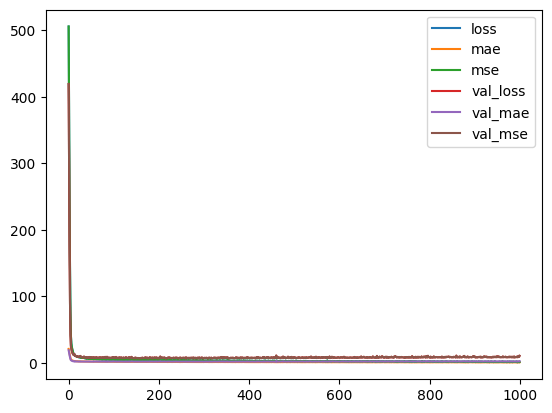

In [47]:
history_df = pd.DataFrame(history.history).plot()

¿Alguna conclusión respecto a este gráfico?

Aprende muy rápidamente y  partir del epoch 100 o así, el error ya no baja tanto. Se podían haber quitado 800 epochs y sería más eficiente

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [ ]:
# Creo que no 
loss, mae_test, mse_test = model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 19.4066 - mae: 3.0251 - mse: 19.4066


In [49]:
print (loss)
print (mae_test)
print (mse_test)

19.406641006469727
3.0250518321990967
19.406641006469727


Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [51]:
# Tomamos los primeros 10 ejemplos del set de prueba
etiquetas = y_test[:10]

# Realizamos la predicción
predicciones = model.predict(X_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

In [54]:
predicciones

array([[36.32241 ],
       [14.474545],
       [30.69577 ],
       [34.911037],
       [19.032347],
       [23.773273],
       [42.49616 ],
       [20.436346],
       [13.998488],
       [15.320886]], dtype=float32)

In [53]:
y_test

385    38.0
124    11.0
237    30.5
391    36.0
292    18.5
       ... 
353    33.0
138    14.0
174    18.0
309    41.5
263    17.7
Name: MPG, Length: 98, dtype: float64

Text(0.5, 1.0, 'Predicciones vs Valores Reales')

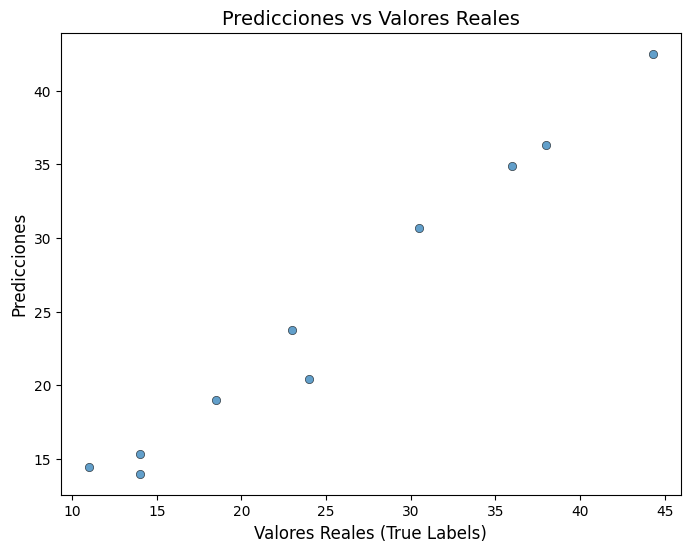

In [58]:
plt.figure(figsize=(8, 6))
plt.scatter(etiquetas, predicciones, alpha=0.7, edgecolors='k', linewidth=0.5)
# Etiquetas y título
plt.xlabel('Valores Reales (True Labels)', fontsize=12)
plt.ylabel('Predicciones', fontsize=12)
plt.title('Predicciones vs Valores Reales', fontsize=14)

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

<Axes: ylabel='Count'>

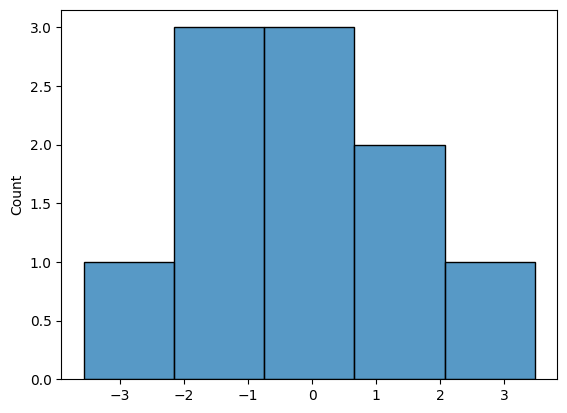

In [60]:
etiquetas_array = np.array(etiquetas).flatten()
predicciones_array = np.array(predicciones).flatten()

errores = predicciones_array - etiquetas_array
sns.histplot(errores)

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [61]:
model.save("coches_model.keras")

## Conclusion